Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
train_transaction = pd.read_csv("../data/raw/train_transaction.csv")
train_identity = pd.read_csv("../data/raw/train_identity.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


Check Data

In [4]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Check Shape

In [5]:
print(train_transaction.shape)

(590540, 394)


Check Missing Values

In [6]:
train_transaction.isnull().sum().sort_values(ascending=False).head(20)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
dtype: int64

Fraud Distribution

In [7]:
train_transaction['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [8]:
train_transaction['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

Visualize Fraud Distribution

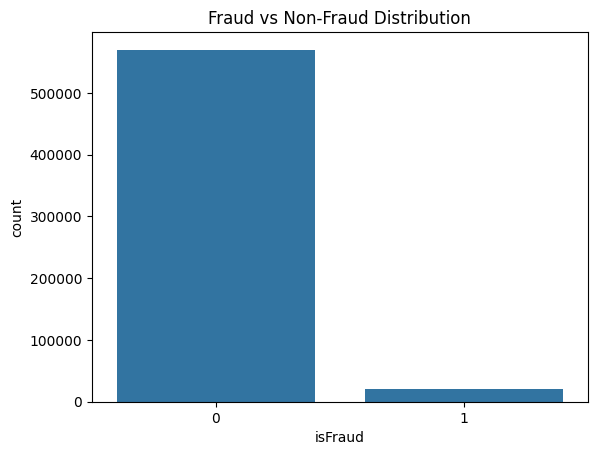

In [9]:
sns.countplot(x='isFraud', data=train_transaction)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

Check Transaction Amount

In [10]:
train_transaction['TransactionAmt'].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

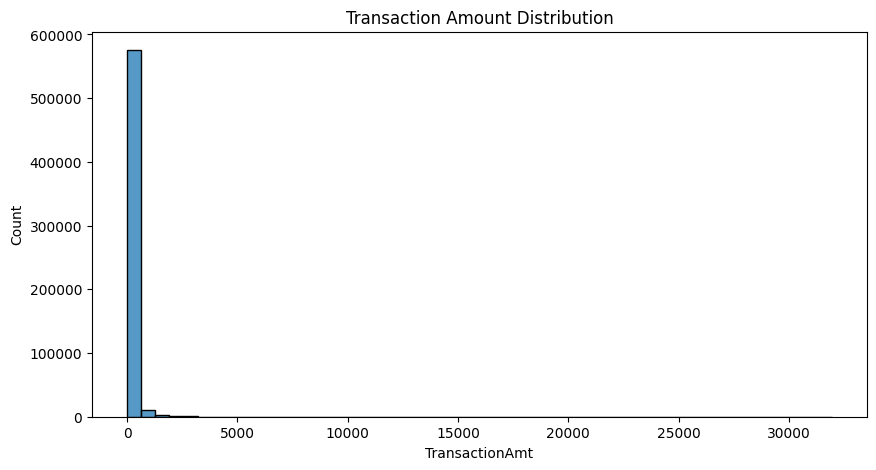

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(train_transaction['TransactionAmt'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

Fraud vs Amount

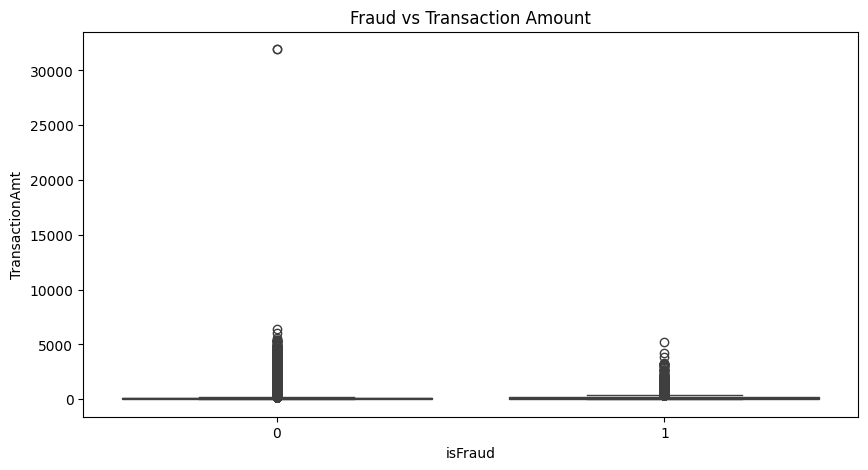

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y='TransactionAmt', data=train_transaction)
plt.title("Fraud vs Transaction Amount")
plt.show()

Merge Identity Dataset

In [13]:
train = train_transaction.merge(
    train_identity,
    on='TransactionID',
    how='left'
)

print(train.shape)

(590540, 434)


Check Missing Values 

In [14]:
missing = train.isnull().sum().sort_values(ascending=False)
missing.head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
id_09    515614
dtype: int64

Check Data Types


In [15]:
train.dtypes.value_counts()

float64    399
str         31
int64        4
Name: count, dtype: int64

Check Target Variable

In [16]:
train['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [17]:
train['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

Memory Optimization

In [18]:
train.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


Check Categorical Columns

In [19]:
cat_cols = train.select_dtypes(include='object').columns
print(cat_cols)

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType',
       'DeviceInfo'],
      dtype='str')


C:\Users\mehta\AppData\Local\Temp\ipykernel_32612\2238862952.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns


Check Missing Values Percentage

In [20]:
missing_percent = train.isnull().mean() * 100
missing_percent.sort_values(ascending=False).head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64

Remove High Missing Columns

In [21]:
cols_to_drop = missing_percent[missing_percent > 80].index
train = train.drop(columns=cols_to_drop)


print("Columns removed:", len(cols_to_drop))
print("New shape:", train.shape)

Columns removed: 74
New shape: (590540, 360)


Separate Numerical & Categorical

In [22]:
num_cols = train.select_dtypes(include=['int64','float64']).columns
cat_cols = train.select_dtypes(include='object').columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 334
Categorical columns: 26


C:\Users\mehta\AppData\Local\Temp\ipykernel_32612\557275519.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns


Fill Missing Values

In [23]:
#fill numerical 
train[num_cols] = train[num_cols].fillna(train[num_cols].median())

#fill categorical
train[cat_cols] = train[cat_cols].fillna('Unknown')

print("Missing values handled successfully")


Missing values handled successfully


Verify Missing Values

In [24]:
train.isna().sum().sum()

np.int64(0)

save cleaned dataset

In [25]:
train.to_csv("../data/processed/train_cleaned.csv", index=False)

print("Cleaned dataset saved")

Cleaned dataset saved
